# Naive Bayes Classifier - NASA NEO Dataset
### Inferential Statistics Project
**Dataset:** NASA Near-Earth Objects  
**Task:** Binary Classification - Hazardous or Not


## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings, json
warnings.filterwarnings('ignore')
np.random.seed(42)


## 1. Data Preprocessing

In [ ]:
df = pd.read_csv('nasa.csv')
print(df.shape)
df.head()


(4687, 40)


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [ ]:
print("class distribution:")
print(df['Hazardous'].value_counts())
print("\nmissing values:", df.isnull().sum().sum())


class distribution:
Hazardous
False    3932
True      755
Name: count, dtype: int64

missing values: 0


In [ ]:
# dropping columns that are just the same thing in different units
# keeping only one version of diameter, velocity, and miss distance
# also removing id/name/date columns that dont help prediction

drop_cols = [
    'Est Dia in KM(min)', 'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)',
    'Neo Reference ID', 'Name', 'Close Approach Date',
    'Orbit Determination Date', 'Epoch Date Close Approach',
    'Epoch Osculation', 'Perihelion Time', 'Equinox', 'Orbiting Body', 'Orbit ID'
]

df_clean = df.drop(columns=drop_cols)
df_clean['Hazardous'] = df_clean['Hazardous'].astype(int)

print(f"features before: {df.shape[1]-1}")
print(f"features after:  {df_clean.shape[1]-1}")
print(df_clean.columns.tolist())


features before: 39
features after:  17
['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per sec', 'Miss Dist.(Astronomical)', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion', 'Hazardous']


## 2. Feature Selection (All vs Reduced)

In [ ]:
# selected features - picked ones that are physically different from each other
# removed highly correlated ones

SELECTED_FEATURES = [
    'Absolute Magnitude',
    'Est Dia in KM(max)',
    'Relative Velocity km per sec',
    'Miss Dist.(Astronomical)',
    'Minimum Orbit Intersection',
    'Orbit Uncertainity',
    'Eccentricity',
    'Semi Major Axis',
    'Inclination',
    'Orbital Period'
]

X_all = df_clean.drop('Hazardous', axis=1)
y     = df_clean['Hazardous']
X_red = df_clean[SELECTED_FEATURES]

removed = [c for c in X_all.columns if c not in SELECTED_FEATURES]
print("removed from reduced set:", removed)

X_all_tr, X_all_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)
X_red_tr, X_red_te, _,   _     = train_test_split(X_red, y, test_size=0.2, random_state=42, stratify=y)

print(f"\ntrain: {len(y_tr)} | test: {len(y_te)}")


removed from reduced set: ['Jupiter Tisserand Invariant', 'Asc Node Longitude', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Mean Anomaly', 'Mean Motion']

train: 3749 | test: 938


## 3. Naive Bayes - From Scratch

In [ ]:
# implementing gaussian naive bayes

# using log probabilities

class GaussianNBScratch:

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y)
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_  = {}
        self.stds_   = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(y)         # P(Y=c)
            self.means_[c]  = Xc.mean(axis=0)           # mean per feature
            self.stds_[c]   = Xc.std(axis=0) + 1e-9    # std per feature, +epsilon to avoid /0

        return self

    def _log_gaussian(self, x, mean, std):
        # log of gaussian pdf
        return -0.5 * np.log(2 * np.pi * std**2) - ((x - mean)**2) / (2 * std**2)

    def predict_proba(self, X):
        X = np.array(X, dtype=float)
        log_posts = []

        for c in self.classes_:
            log_prior      = np.log(self.priors_[c])
            log_likelihood = self._log_gaussian(X, self.means_[c], self.stds_[c]).sum(axis=1)
            log_posts.append(log_prior + log_likelihood)

        log_posts = np.array(log_posts).T
        # normalize
        log_posts -= log_posts.max(axis=1, keepdims=True)
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


In [ ]:
# train on all features
nb_sc_all = GaussianNBScratch().fit(X_all_tr, y_tr)
y_pred_sc_all = nb_sc_all.predict(X_all_te)

# train on reduced features
nb_sc_red = GaussianNBScratch().fit(X_red_tr, y_tr)
y_pred_sc_red = nb_sc_red.predict(X_red_te)

print("scratch - all features")
print(f"  accuracy:  {accuracy_score(y_te, y_pred_sc_all):.4f}")
print(f"  precision: {precision_score(y_te, y_pred_sc_all):.4f}")
print(f"  recall:    {recall_score(y_te, y_pred_sc_all):.4f}")
print(f"  f1:        {f1_score(y_te, y_pred_sc_all):.4f}")

print("\nscratch - reduced features")
print(f"  accuracy:  {accuracy_score(y_te, y_pred_sc_red):.4f}")
print(f"  precision: {precision_score(y_te, y_pred_sc_red):.4f}")
print(f"  recall:    {recall_score(y_te, y_pred_sc_red):.4f}")
print(f"  f1:        {f1_score(y_te, y_pred_sc_red):.4f}")


scratch - all features
  accuracy:  0.9542
  precision: 0.8750
  recall:    0.8344
  f1:        0.8542

scratch - reduced features
  accuracy:  0.9606
  precision: 0.9071
  recall:    0.8411
  f1:        0.8729


## 4. Naive Bayes - sklearn

In [ ]:
gnb_all = GaussianNB()
gnb_all.fit(X_all_tr, y_tr)
y_pred_sk_all = gnb_all.predict(X_all_te)

gnb_red = GaussianNB()
gnb_red.fit(X_red_tr, y_tr)
y_pred_sk_red = gnb_red.predict(X_red_te)

print("sklearn - all features")
print(f"  accuracy:  {accuracy_score(y_te, y_pred_sk_all):.4f}")
print(f"  precision: {precision_score(y_te, y_pred_sk_all):.4f}")
print(f"  recall:    {recall_score(y_te, y_pred_sk_all):.4f}")
print(f"  f1:        {f1_score(y_te, y_pred_sk_all):.4f}")

print("\nsklearn - reduced features")
print(f"  accuracy:  {accuracy_score(y_te, y_pred_sk_red):.4f}")
print(f"  precision: {precision_score(y_te, y_pred_sk_red):.4f}")
print(f"  recall:    {recall_score(y_te, y_pred_sk_red):.4f}")
print(f"  f1:        {f1_score(y_te, y_pred_sk_red):.4f}")


sklearn - all features
  accuracy:  0.9456
  precision: 0.8247
  recall:    0.8411
  f1:        0.8328

sklearn - reduced features
  accuracy:  0.9499
  precision: 0.8421
  recall:    0.8477
  f1:        0.8449


## 5. Results Comparison

In [ ]:
def get_metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred)]

results = {
    'Scratch - All'    : get_metrics(y_te, y_pred_sc_all),
    'Scratch - Reduced': get_metrics(y_te, y_pred_sc_red),
    'sklearn - All'    : get_metrics(y_te, y_pred_sk_all),
    'sklearn - Reduced': get_metrics(y_te, y_pred_sk_red),
}

summary = pd.DataFrame(results, index=['Accuracy','Precision','Recall','F1']).T
print(summary.round(4).to_string())


                   Accuracy  Precision  Recall      F1
Scratch - All        0.9542     0.8750  0.8344  0.8542
Scratch - Reduced    0.9606     0.9071  0.8411  0.8729
sklearn - All        0.9456     0.8247  0.8411  0.8328
sklearn - Reduced    0.9499     0.8421  0.8477  0.8449


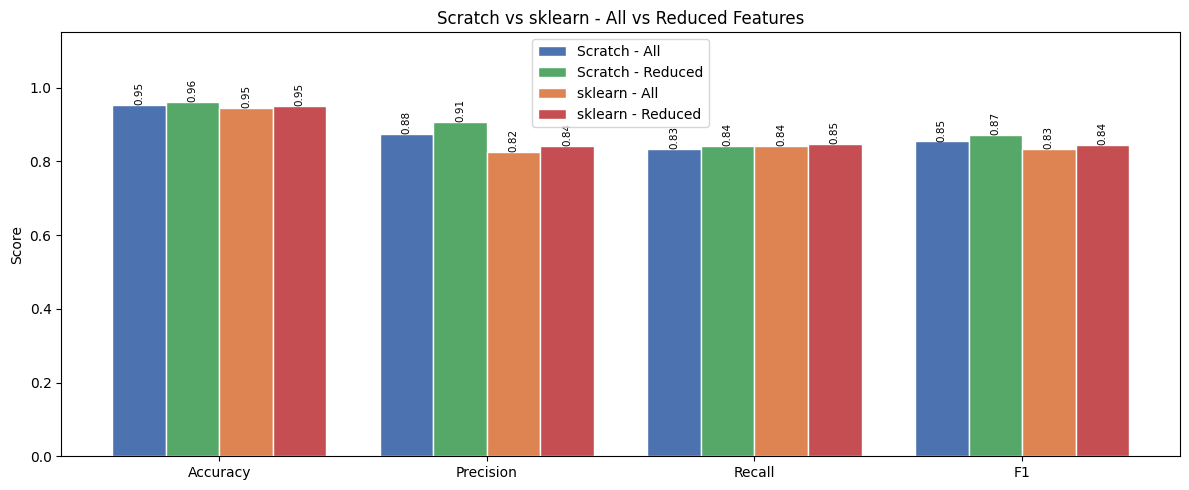

In [ ]:
# bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_names))
width = 0.2
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

for i, (label, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*width, vals, width, label=label, color=colors[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', fontsize=7.5, rotation=90)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Scratch vs sklearn - All vs Reduced Features')
ax.legend()
plt.tight_layout()
plt.savefig('comparison_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
